In [1]:
%matplotlib inline
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader,Dataset
import matplotlib.pyplot as plt
import torchvision.utils
import numpy as np
import random
from PIL import Image
import torch
from torch.autograd import Variable
import PIL.ImageOps    
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

# Video Preprocessing

In [2]:
import cv2
import os

def extract_and_save_frame(video_folder, output_folder):
    # 저장 폴더가 존재하지 않으면 생성
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 동영상 파일 목록 가져오기 (확장자를 .mpeg으로 변경)
    video_files = [f for f in os.listdir(video_folder) if f.endswith('.mpeg')]

    # 모든 동영상 파일에 대해 처리
    for video_file in video_files:
        video_path = os.path.join(video_folder, video_file)
        cap = cv2.VideoCapture(video_path)
    
        if not cap.isOpened():
            print(f"Cannot open video {video_file}")
            continue
    
        # FPS (초당 프레임 수) 가져오기
        fps = cap.get(cv2.CAP_PROP_FPS)
        
        # 2초에 해당하는 프레임 번호 계산
        one_second_frame = int(fps * 2)
        
        frame_count = 0
        saved = False  # 프레임 저장 여부 확인
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            # 2초에 해당하는 프레임일 때만 저장하고, 한 번만 저장하도록 설정
            if frame_count == one_second_frame and not saved:
                # 저장 경로와 파일명 지정
                output_filename = os.path.join(output_folder, f"{video_file[:-5]}_frame.jpg")
                cv2.imwrite(output_filename, frame)
                saved = True  # 한 번 저장했으므로 이후 저장하지 않음
            
            frame_count += 1
    
        cap.release()
    
    print("프레임 저장 완료!")

In [3]:
# 원본 영상 이미지 추출 -> train 폴더에 저장
extract_and_save_frame("original_video", "train_data/video1")

# 원본 영상 이미지 추출 -> test 폴더에 저장
extract_and_save_frame("original_video", "test_data/original")

# 왜곡 영상 이미지 추출 -> train 폴더에 저장
extract_and_save_frame("distorted_video", "train_data/video1")

# 왜곡 영상 이미지 추출 -> test 폴더에 저장
extract_and_save_frame("distorted_video", "test_data/video1")

# 노이즈 영상 이미지 추출 -> train 폴더에 저장
extract_and_save_frame("noise_video", "train_data/video2")

# 노이즈 영상 이미지 추출 -> test 폴더에 저장
extract_and_save_frame("noise_video", "test_data/video2")

프레임 저장 완료!
프레임 저장 완료!
프레임 저장 완료!
프레임 저장 완료!
프레임 저장 완료!
프레임 저장 완료!


# Train code

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

# for reproducibility
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

cuda


In [5]:
def imshow(img,text=None,should_save=False):
    npimg = img.numpy()
    plt.axis("off")
    if text:
        plt.text(75, 8, text, style='italic',fontweight='bold',
            bbox={'facecolor':'white', 'alpha':0.8, 'pad':10})
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()    

def show_plot(iteration,loss):
    plt.plot(iteration,loss)
    plt.show()

In [6]:
class Config():
    training_dir = "train_data/"
    testing_dir = "test_data/"
    train_batch_size = 8
    train_number_epochs = 200

In [7]:
folder_dataset = dset.ImageFolder(root=Config.training_dir)

In [8]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.cnn1 = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(3, 4, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(4),
            
            nn.ReflectionPad2d(1),
            nn.Conv2d(4, 8, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(8),


            nn.ReflectionPad2d(1),
            nn.Conv2d(8, 8, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(8),


        )

        self.fc1 = nn.Sequential(
            nn.Linear(8*100*100, 500),
            nn.ReLU(inplace=True),

            nn.Linear(500, 500),
            nn.ReLU(inplace=True),

            nn.Linear(500, 5))

    def forward_once(self, x):
        output = self.cnn1(x)
        output = output.view(output.size()[0], -1)
        output = self.fc1(output)
        return output

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

In [9]:
class SiameseNetworkDataset(Dataset):
    
    def __init__(self,imageFolderDataset,transform=None,should_invert=True):
        self.imageFolderDataset = imageFolderDataset    
        self.transform = transform
        self.should_invert = should_invert
        
    def __getitem__(self,index):
        img0_tuple = random.choice(self.imageFolderDataset.imgs)
        #we need to make sure approx 50% of images are in the same class
        should_get_same_class = random.randint(0,1) 
        if should_get_same_class:
            while True:
                #keep looping till the same class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs) 
                if img0_tuple[1]==img1_tuple[1]:
                    break
        else:
            while True:
                #keep looping till a different class image is found
                
                img1_tuple = random.choice(self.imageFolderDataset.imgs) 
                if img0_tuple[1] !=img1_tuple[1]:
                    break

        img0 = Image.open(img0_tuple[0])
        img1 = Image.open(img1_tuple[0])
        
        if self.should_invert:
            img0 = PIL.ImageOps.invert(img0)
            img1 = PIL.ImageOps.invert(img1)

        if self.transform is not None:
            img0 = self.transform(img0)
            img1 = self.transform(img1)
        
        return img0, img1 , torch.from_numpy(np.array([int(img1_tuple[1]!=img0_tuple[1])],dtype=np.float32))
    
    def __len__(self):
        return len(self.imageFolderDataset.imgs)

In [10]:
siamese_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset,
                                        transform=transforms.Compose([transforms.Resize((100,100)),
                                                                      transforms.ToTensor()
                                                                      ])
                                       ,should_invert=False)

In [11]:
class ContrastiveLoss(torch.nn.Module):
    """
    Contrastive loss function.
    Based on: http://yann.lecun.com/exdb/publis/pdf/hadsell-chopra-lecun-06.pdf
    """

    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim = True)
        loss_contrastive = torch.mean((1-label) * torch.pow(euclidean_distance, 2) +
                                      (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))


        return loss_contrastive

In [12]:
train_dataloader = DataLoader(siamese_dataset,
                        shuffle=True,
                        num_workers=0,
                        batch_size=Config.train_batch_size)

In [13]:
net = SiameseNetwork().cuda()
criterion = ContrastiveLoss()
optimizer = optim.Adam(net.parameters(),lr = 0.0005 )

In [14]:
counter = []
loss_history = [] 
iteration_number= 0

Epoch number 0 Current loss 1.9502183198928833
Epoch number 0 Current loss 28.52716827392578
Epoch number 1 Current loss 35.4665641784668
Epoch number 1 Current loss 51.77817916870117
Epoch number 2 Current loss 7.970593452453613
Epoch number 2 Current loss 37.179283142089844
Epoch number 3 Current loss 64.81242370605469
Epoch number 3 Current loss 12.383968353271484
Epoch number 4 Current loss 19.41487693786621
Epoch number 4 Current loss 31.736948013305664
Epoch number 5 Current loss 11.41399097442627
Epoch number 5 Current loss 47.96773910522461
Epoch number 6 Current loss 1.14830482006073
Epoch number 6 Current loss 7.529421806335449
Epoch number 7 Current loss 0.21324339509010315
Epoch number 7 Current loss 4.375674247741699
Epoch number 8 Current loss 6.601579666137695
Epoch number 8 Current loss 0.9698748588562012
Epoch number 9 Current loss 4.431987762451172
Epoch number 9 Current loss 6.376752853393555
Epoch number 10 Current loss 4.459407806396484
Epoch number 10 Current loss

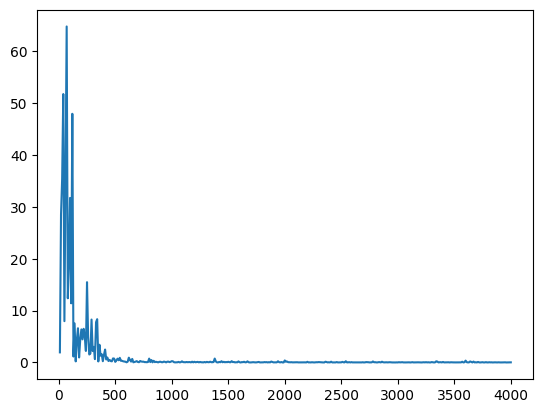

In [15]:
for epoch in range(0,Config.train_number_epochs):
    for i, data in enumerate(train_dataloader, 0):
        img0, img1 , label = data
        img0, img1 , label = img0.cuda(), img1.cuda() , label.cuda()
        optimizer.zero_grad()
        output1,output2 = net(img0,img1)
        loss_contrastive = criterion(output1,output2,label)
        loss_contrastive.backward()
        optimizer.step()
        if i %10 == 0 :
            print("Epoch number {} Current loss {}".format(epoch,loss_contrastive.item()))
            iteration_number +=10
            counter.append(iteration_number)
            loss_history.append(loss_contrastive.item())
show_plot(counter,loss_history)

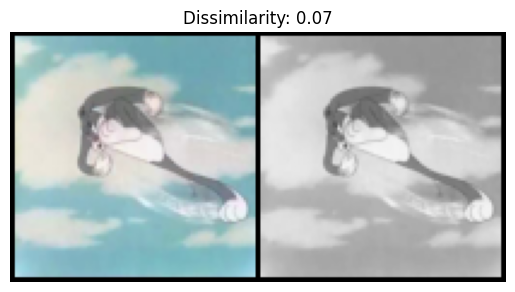

In [16]:
import torch
from torch.autograd import Variable
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms
import torchvision.utils as utils
import matplotlib.pyplot as plt

# 두 개의 이미지 경로 지정
image_path1 = "test_data/original/Falling Hare (1943)_frame.jpg"
image_path2 = "test_data/video1/2_frame.jpg"

# 이미지 전처리
transform = transforms.Compose([transforms.Resize((100, 100)), transforms.ToTensor()])

# 첫 번째 이미지 불러오기 및 전처리
image1 = Image.open(image_path1)  # 컬러 이미지를 그대로 불러옵니다.
image1 = transform(image1).unsqueeze(0)  # 배치 차원 추가

# 두 번째 이미지 불러오기 및 전처리
image2 = Image.open(image_path2)  # 컬러 이미지를 그대로 불러옵니다.
image2 = transform(image2).unsqueeze(0)  # 배치 차원 추가

# GPU로 이미지 전송
image1 = Variable(image1).cuda()
image2 = Variable(image2).cuda()

# 유사도 측정
output1, output2 = net(image1, image2)
euclidean_distance = F.pairwise_distance(output1, output2)

# 두 이미지를 나란히 보여주며 유사도 출력
concatenated = torch.cat((image1.cpu(), image2.cpu()), 0)
plt.imshow(utils.make_grid(concatenated, nrow=2).permute(1, 2, 0))
plt.title(f'Dissimilarity: {euclidean_distance.item():.2f}')
plt.axis('off')
plt.show()

Comparing with images from folder 1:
Image Name - Euclidean Distance (Similarity)
10_frame.jpg - 0.03
11_frame.jpg - 0.06
12_frame.jpg - 0.16
13_frame.jpg - 0.15
14_frame.jpg - 0.17
15_frame.jpg - 0.38
16_frame.jpg - 0.16
17_frame.jpg - 0.09
18_frame.jpg - 0.19
19_frame.jpg - 0.12
1_frame.jpg - 0.15
20_frame.jpg - 0.07
21_frame.jpg - 0.35
22_frame.jpg - 0.17
23_frame.jpg - 0.24
25_frame.jpg - 0.13
26_frame.jpg - 0.16
27_frame.jpg - 0.13
28_frame.jpg - 0.15
29_frame.jpg - 0.25
2_frame.jpg - 0.07
30_frame.jpg - 0.19
31_frame.jpg - 0.22
32_frame.jpg - 0.14
33_frame.jpg - 0.09
34_frame.jpg - 0.13
35_frame.jpg - 0.17
36_frame.jpg - 0.16
37_frame.jpg - 0.28
3_frame.jpg - 0.15
42_frame.jpg - 0.13
43_frame.jpg - 0.12
44_frame.jpg - 0.19
45_frame.jpg - 0.20
46_frame.jpg - 0.27
47_frame.jpg - 0.10
48_frame.jpg - 0.09
49_frame.jpg - 0.10
4_frame.jpg - 0.07
50_frame.jpg - 0.18
51_frame.jpg - 0.18
5_frame.jpg - 0.01
60_frame.jpg - 0.19
61_frame.jpg - 0.15
62_frame.jpg - 0.20
63_frame.jpg - 0.16
64_

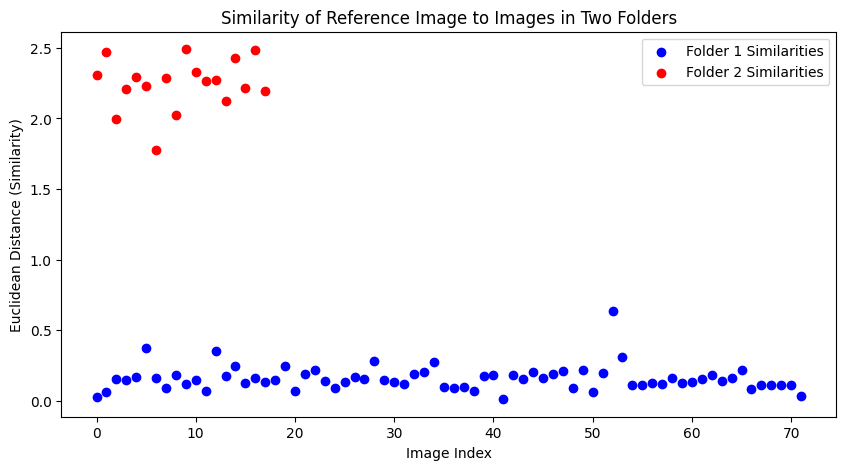

In [17]:
# 기준이 되는 이미지 경로
reference_image_path = "test_data/original/Falling Hare (1943)_frame.jpg"

# 비교할 이미지 폴더 경로
comparison_directory1 = "test_data/video1"
comparison_directory2 = "test_data/video2"

# 이미지 전처리 설정
transform = transforms.Compose([transforms.Resize((100, 100)), transforms.ToTensor()])

# 기준 이미지 불러오기 및 전처리
reference_image = Image.open(reference_image_path)
reference_image = transform(reference_image).unsqueeze(0).cuda()

# 모든 비교 이미지에 대해 유사도 계산
similarities1 = []
similarities2 = []
comparison_images1 = os.listdir(comparison_directory1)
comparison_images2 = os.listdir(comparison_directory2)

# 첫 번째 폴더의 유사도 계산
print("Comparing with images from folder 1:")
print("Image Name - Euclidean Distance (Similarity)")
for image_name in comparison_images1:
    image_path = os.path.join(comparison_directory1, image_name)
    comparison_image = Image.open(image_path)
    comparison_image = transform(comparison_image).unsqueeze(0).cuda()

    # 유사도 계산
    output1, output2 = net(Variable(reference_image), Variable(comparison_image))
    euclidean_distance = F.pairwise_distance(output1, output2)
    distance_value = euclidean_distance.item()

    # 유사도 결과를 리스트에 저장하고, 이름과 함께 출력
    similarities1.append(distance_value)
    print(f"{image_name} - {distance_value:.2f}")

# 두 번째 폴더의 유사도 계산
print("\nComparing with images from folder 2:")
print("Image Name - Euclidean Distance (Similarity)")
for image_name in comparison_images2:
    image_path = os.path.join(comparison_directory2, image_name)
    comparison_image = Image.open(image_path)
    comparison_image = transform(comparison_image).unsqueeze(0).cuda()

    # 유사도 계산
    output1, output2 = net(Variable(reference_image), Variable(comparison_image))
    euclidean_distance = F.pairwise_distance(output1, output2)
    distance_value = euclidean_distance.item()

    # 유사도 결과를 리스트에 저장하고, 이름과 함께 출력
    similarities2.append(distance_value)
    print(f"{image_name} - {distance_value:.2f}")

# 유사도 결과 그래프 출력
plt.figure(figsize=(10, 5))

# 첫 번째 폴더의 유사도 점
plt.scatter(range(len(similarities1)), similarities1, color='blue', label='Folder 1 Similarities')

# 두 번째 폴더의 유사도 점
plt.scatter(range(len(similarities2)), similarities2, color='red', label='Folder 2 Similarities')

plt.xlabel("Image Index")
plt.ylabel("Euclidean Distance (Similarity)")
plt.title("Similarity of Reference Image to Images in Two Folders")
plt.legend()
plt.show()

In [18]:
# 모델을 저장할 경로와 파일 이름 지정
model_save_path = "siamese_network_final.pth"

# 최종 모델 저장
torch.save(net.state_dict(), model_save_path)
print(f"모델이 저장되었습니다.")

모델이 저장되었습니다.


# Test code

C:\Users\user\AppData\Local\Temp\ipykernel_21408\3099267806.py:62: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load("siamese_network_final.pth", 

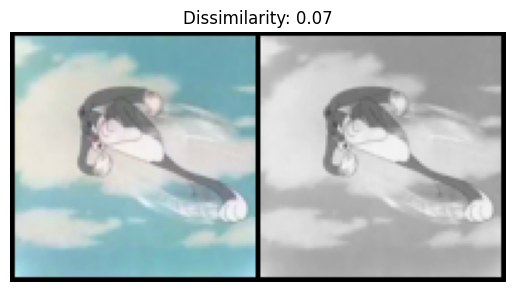

검출 가능한 이미지입니다


In [19]:
import torchvision
import torch
from torch.autograd import Variable
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import torchvision.utils as utils
import numpy as np
import random
from PIL import Image
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import cv2

class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.cnn1 = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(3, 4, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(4),
            
            nn.ReflectionPad2d(1),
            nn.Conv2d(4, 8, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(8),


            nn.ReflectionPad2d(1),
            nn.Conv2d(8, 8, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(8),

        )

        self.fc1 = nn.Sequential(
            nn.Linear(8*100*100, 500),
            nn.ReLU(inplace=True),

            nn.Linear(500, 500),
            nn.ReLU(inplace=True),

            nn.Linear(500, 5))

    def forward_once(self, x):
        output = self.cnn1(x)
        output = output.view(output.size()[0], -1)
        output = self.fc1(output)
        return output

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2
    

# 모델 초기화 및 가중치 불러오기
net = SiameseNetwork()
net.load_state_dict(torch.load("siamese_network_final.pth", map_location=torch.device('cpu')))

# 지정된 초의 프레임을 가져오는 함수
def get_frame_from_video(video_path, seconds):
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)  # 영상의 초당 프레임 수
    frame_id = int(fps * seconds)  # 원하는 시간대의 프레임 번호

    # 해당 프레임으로 이동
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame = cap.read()

    cap.release()

    if ret:
        # 프레임을 PIL 이미지로 변환
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return Image.fromarray(frame_rgb)
    else:
        print(f"Could not retrieve frame at {seconds} seconds.")
        return None

# 이미지 시각화 함수
def imshow(img, text=None, should_save=False):
    npimg = img.numpy()
    plt.axis("off")
    if text:
        plt.text(75, 8, text, style='italic', fontweight='bold',
                 bbox={'facecolor':'white', 'alpha':0.8, 'pad':10})
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()    

# 손실 그래프 시각화 함수
def show_plot(iteration, loss):
    plt.plot(iteration, loss)
    plt.show()



# video 경로 설정 
video_path1 = "original_video/Falling Hare (1943).mpeg"
video_path2 = "all_videos/2.mpeg"

# 비교할 프레임 시간 선정 
seconds = 2

# 이미지 전처리
transform = transforms.Compose([transforms.Resize((100, 100)), transforms.ToTensor()])

comparison_image1 = get_frame_from_video(video_path1, seconds)
comparison_image1 = transform(comparison_image1).unsqueeze(0)

comparison_image2 = get_frame_from_video(video_path2, seconds)
comparison_image2 = transform(comparison_image2).unsqueeze(0)

# CPU로 이미지 전송
image1 = Variable(comparison_image1)
image2 = Variable(comparison_image2)

# 유사도 측정
output1, output2 = net(image1, image2)
euclidean_distance = F.pairwise_distance(output1, output2)

# 두 이미지를 나란히 보여주며 유사도 출력
concatenated = torch.cat((image1, image2), 0)
plt.imshow(utils.make_grid(concatenated, nrow=2).permute(1, 2, 0))
plt.title(f'Dissimilarity: {euclidean_distance.item():.2f}')
plt.axis('off')
plt.show()

val = float(f'{euclidean_distance.item():.2f}')
if 0.0 < val < 1.5 :
    print("검출 가능한 이미지입니다")
elif val == 0.0:
    print("원본 이미지 입니다.")
elif val >= 1.5 :
    print("검출할 수 없는 이미지입니다.")

C:\Users\user\AppData\Local\Temp\ipykernel_21408\1438385362.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load("siamese_network_final.pth", 

Comparing with images :
Image Name - Euclidean Distance (Similarity)
1.mpeg - 0.15
10.mpeg - 0.03
11.mpeg - 0.06
12.mpeg - 0.16
13.mpeg - 0.15
14.mpeg - 0.17
15.mpeg - 0.38
16.mpeg - 0.15
17.mpeg - 0.09
18.mpeg - 0.19
19.mpeg - 0.12
2.mpeg - 0.07
20.mpeg - 0.07
21.mpeg - 0.35
22.mpeg - 0.17
23.mpeg - 0.24
24.mpeg - 2.31
25.mpeg - 0.13
26.mpeg - 0.16
27.mpeg - 0.13
28.mpeg - 0.15
29.mpeg - 0.25
3.mpeg - 0.15
30.mpeg - 0.19
31.mpeg - 0.22
32.mpeg - 0.13
33.mpeg - 0.09
34.mpeg - 0.13
35.mpeg - 0.17
36.mpeg - 0.16
37.mpeg - 0.28
38.mpeg - 2.47
39.mpeg - 2.0
4.mpeg - 0.07
40.mpeg - 2.21
41.mpeg - 2.29
42.mpeg - 0.13
43.mpeg - 0.12
44.mpeg - 0.18
45.mpeg - 0.2
46.mpeg - 0.27
47.mpeg - 0.1
48.mpeg - 0.09
49.mpeg - 0.1
5.mpeg - 0.01
50.mpeg - 0.18
51.mpeg - 0.18
52.mpeg - 2.23
53.mpeg - 1.78
54.mpeg - 2.28
55.mpeg - 2.02
56.mpeg - 2.49
57.mpeg - 2.33
58.mpeg - 2.27
59.mpeg - 2.27
6.mpeg - 0.63
60.mpeg - 0.18
61.mpeg - 0.16
62.mpeg - 0.2
63.mpeg - 0.16
64.mpeg - 0.19
65.mpeg - 0.21
66.mpeg - 0.

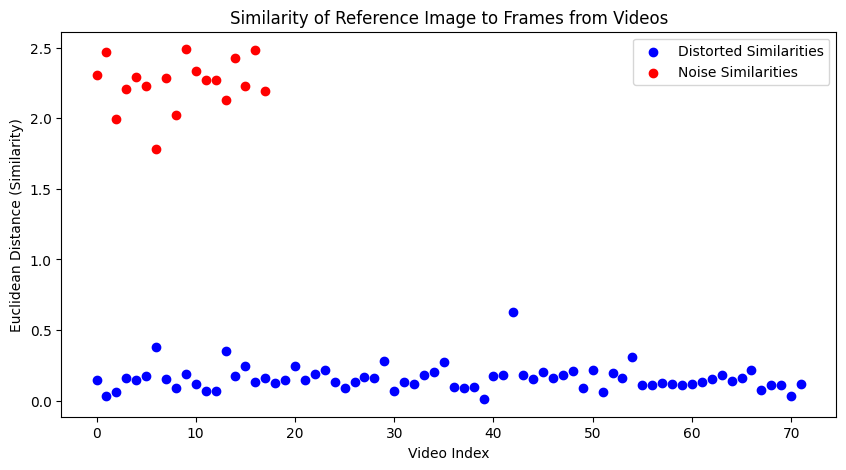

In [20]:
import torchvision
import torch
from torch.autograd import Variable
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import torchvision.utils as utils
import numpy as np
import random
from PIL import Image
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import cv2
import os

class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.cnn1 = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(3, 4, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(4),
            
            nn.ReflectionPad2d(1),
            nn.Conv2d(4, 8, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(8),


            nn.ReflectionPad2d(1),
            nn.Conv2d(8, 8, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(8),

        )

        self.fc1 = nn.Sequential(
            nn.Linear(8*100*100, 500),
            nn.ReLU(inplace=True),

            nn.Linear(500, 500),
            nn.ReLU(inplace=True),

            nn.Linear(500, 5))

    def forward_once(self, x):
        output = self.cnn1(x)
        output = output.view(output.size()[0], -1)
        output = self.fc1(output)
        return output

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

# 기준이 되는 영상 경로 및 초
reference_video_path = "original_video/Falling Hare (1943).mpeg"
reference_second = 2  # 기준으로 사용할 초

# 비교할 영상 폴더 경로
comparison_directory = "all_videos"

# 이미지 전처리 설정
transform = transforms.Compose([transforms.Resize((100, 100)), transforms.ToTensor()])

# 모델을 CPU에 로드
net = SiameseNetwork()  # 이전에 정의한 시암 네트워크 클래스 사용
net.load_state_dict(torch.load("siamese_network_final.pth", map_location=torch.device('cpu')))
net.to(torch.device('cpu'))  # 모델을 CPU로 이동

# 영상에서 프레임을 추출하는 함수
def extract_frame(video_path, second):
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():  # 비디오가 열리지 않은 경우 처리
        raise ValueError(f"Could not open video file: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)  # 비디오의 초당 프레임 수
    frame_number = int(fps * second)  # 초를 프레임 번호로 변환
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)  # 프레임 설정

    ret, frame = cap.read()  # 프레임 읽기
    cap.release()  # 비디오 캡처 객체 해제

    if ret:
        return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))  # 이미지를 RGB로 변환하여 반환
    else:
        raise ValueError("Could not read frame from video.")

# 기준 이미지 불러오기 및 전처리 (영상에서 특정 초의 프레임으로 대체)
reference_image = extract_frame(reference_video_path, reference_second)  # 특정 초의 프레임 추출
reference_image = transform(reference_image).unsqueeze(0)  # 배치 차원 추가

# 모든 비교 이미지에 대해 유사도 계산
similarities1 = []
similarities2 = []

# 첫 번째 폴더의 유사도 계산
print("Comparing with images :")
print("Image Name - Euclidean Distance (Similarity)")
noise_video = []
for video_name in os.listdir(comparison_directory):
    video_path = os.path.join(comparison_directory, video_name)
    try:
        comparison_image = extract_frame(video_path, reference_second)  # 특정 초의 프레임 추출
        comparison_image = transform(comparison_image).unsqueeze(0)  # 배치 차원 추가

        # 유사도 계산
        output1, output2 = net(reference_image, comparison_image)
        euclidean_distance = F.pairwise_distance(output1, output2)
        distance_value = euclidean_distance.item()

        val = float(f'{euclidean_distance.item():.2f}')
        print(f"{video_name} - {val}")
        if val > 1.5 :
            noise_video.append(video_name)
            similarities2.append(distance_value)
        else:
            # 유사도 결과를 리스트에 저장하고, 이름과 함께 출력
            similarities1.append(distance_value)
    except Exception as e:
            print(f"Error processing {video_name}: {e}")

    
print('노이즈 영상', noise_video)
        

# 유사도 결과 그래프 출력
plt.figure(figsize=(10, 5))

# 첫 번째 폴더의 유사도 점
plt.scatter(range(len(similarities1)), similarities1, color='blue', label='Distorted Similarities')
plt.scatter(range(len(similarities2)), similarities2, color='red', label='Noise Similarities')

plt.xlabel("Video Index")
plt.ylabel("Euclidean Distance (Similarity)")
plt.title("Similarity of Reference Image to Frames from Videos")
plt.legend()
plt.show()